# Hackathon Notebook

In [81]:
import pandas as pd
import numpy as np
import requests
import seaborn as sns
import matplotlib.pyplot as plt


In [8]:
df = pd.read_csv('data/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [9]:
df['date_added'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 8807 entries, 0 to 8806
Series name: date_added
Non-Null Count  Dtype 
--------------  ----- 
8797 non-null   object
dtypes: object(1)
memory usage: 68.9+ KB


In [10]:
df_clean = df.copy()
df_clean = df_clean.dropna(subset=['date_added'])
df_clean['date_added'] = pd.to_datetime(df_clean['date_added'].str.lstrip(' '), format='%B %d, %Y')
df_clean['month_added'] = df_clean['date_added'].dt.month
df_clean['year_added'] = df_clean['date_added'].dt.year
df_clean.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",9,2021
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",9,2021
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,9,2021
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",9,2021
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,9,2021


In [11]:
df_clean['movie_duration'] = df_clean['duration'].apply(lambda x: int(x.split()[0]) if isinstance(x, str) and 'min' in x.lower() else np.nan)
df_clean['tv_show_seasons'] = df_clean['duration'].apply(lambda x: int(x.split()[0]) if isinstance(x, str) and 'Season' in x else np.nan) 
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8797 entries, 0 to 8806
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   show_id          8797 non-null   object        
 1   type             8797 non-null   object        
 2   title            8797 non-null   object        
 3   director         6173 non-null   object        
 4   cast             7972 non-null   object        
 5   country          7967 non-null   object        
 6   date_added       8797 non-null   datetime64[ns]
 7   release_year     8797 non-null   int64         
 8   rating           8793 non-null   object        
 9   duration         8794 non-null   object        
 10  listed_in        8797 non-null   object        
 11  description      8797 non-null   object        
 12  month_added      8797 non-null   int32         
 13  year_added       8797 non-null   int32         
 14  movie_duration   6128 non-null   float64     

In [12]:
df_clean.at[5541, 'movie_duration'] = 74
df_clean.at[5794, 'movie_duration'] = 84
df_clean.at[5813, 'movie_duration'] = 66

df_clean.at[5541, 'rating'] = 'Not Rated'
df_clean.at[5794, 'rating'] = 'Not Rated'
df_clean.at[5813, 'rating'] = 'Not Rated'

df_clean.at[5541, 'duration'] = '74 min'
df_clean.at[5794, 'duration'] = '84 min'
df_clean.at[5813, 'duration'] = '66 min'

# 5541 - 74
# 5794 - 84
# 5813 - 66

df_clean[(df_clean['type'] == 'Movie') & (df_clean['movie_duration'].isna())]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,year_added,movie_duration,tv_show_seasons


In [13]:
df_clean.reset_index(inplace=True, drop=True)
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8797 entries, 0 to 8796
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   show_id          8797 non-null   object        
 1   type             8797 non-null   object        
 2   title            8797 non-null   object        
 3   director         6173 non-null   object        
 4   cast             7972 non-null   object        
 5   country          7967 non-null   object        
 6   date_added       8797 non-null   datetime64[ns]
 7   release_year     8797 non-null   int64         
 8   rating           8793 non-null   object        
 9   duration         8797 non-null   object        
 10  listed_in        8797 non-null   object        
 11  description      8797 non-null   object        
 12  month_added      8797 non-null   int32         
 13  year_added       8797 non-null   int32         
 14  movie_duration   6131 non-null   float64

In [14]:
df_clean['country'].fillna('Unknown', inplace=True)
df_clean['rating'].fillna('Not Rated', inplace=True)
df_clean['duration'].fillna('Unknown', inplace=True)

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8797 entries, 0 to 8796
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   show_id          8797 non-null   object        
 1   type             8797 non-null   object        
 2   title            8797 non-null   object        
 3   director         6173 non-null   object        
 4   cast             7972 non-null   object        
 5   country          8797 non-null   object        
 6   date_added       8797 non-null   datetime64[ns]
 7   release_year     8797 non-null   int64         
 8   rating           8797 non-null   object        
 9   duration         8797 non-null   object        
 10  listed_in        8797 non-null   object        
 11  description      8797 non-null   object        
 12  month_added      8797 non-null   int32         
 13  year_added       8797 non-null   int32         
 14  movie_duration   6131 non-null   float64

C:\Users\ldtic\AppData\Local\Temp\ipykernel_12584\3068480811.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['country'].fillna('Unknown', inplace=True)
C:\Users\ldtic\AppData\Local\Temp\ipykernel_12584\3068480811.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

In [15]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8797 entries, 0 to 8796
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   show_id          8797 non-null   object        
 1   type             8797 non-null   object        
 2   title            8797 non-null   object        
 3   director         6173 non-null   object        
 4   cast             7972 non-null   object        
 5   country          8797 non-null   object        
 6   date_added       8797 non-null   datetime64[ns]
 7   release_year     8797 non-null   int64         
 8   rating           8797 non-null   object        
 9   duration         8797 non-null   object        
 10  listed_in        8797 non-null   object        
 11  description      8797 non-null   object        
 12  month_added      8797 non-null   int32         
 13  year_added       8797 non-null   int32         
 14  movie_duration   6131 non-null   float64

In [16]:
df_clean['cast'] = df_clean['cast'].str.split(', ')
df_clean['country'] = df_clean['country'].str.split(', ')
df_clean['listed_in'] = df_clean['listed_in'].str.split(', ')
df_clean.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,year_added,movie_duration,tv_show_seasons
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,[United States],2021-09-25,2020,PG-13,90 min,[Documentaries],"As her father nears the end of his life, filmm...",9,2021,90.0,NaN
1,s2,TV Show,Blood & Water,NaN,"[Ama Qamata, Khosi Ngema, Gail Mabalane, Thaba...",[South Africa],2021-09-24,2021,TV-MA,2 Seasons,"[International TV Shows, TV Dramas, TV Mysteries]","After crossing paths at a party, a Cape Town t...",9,2021,NaN,2.0
2,s3,TV Show,Ganglands,Julien Leclercq,"[Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nab...",[Unknown],2021-09-24,2021,TV-MA,1 Season,"[Crime TV Shows, International TV Shows, TV Ac...",To protect his family from a powerful drug lor...,9,2021,NaN,1.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,[Unknown],2021-09-24,2021,TV-MA,1 Season,"[Docuseries, Reality TV]","Feuds, flirtations and toilet talk go down amo...",9,2021,NaN,1.0
4,s5,TV Show,Kota Factory,NaN,"[Mayur More, Jitendra Kumar, Ranjan Raj, Alam ...",[India],2021-09-24,2021,TV-MA,2 Seasons,"[International TV Shows, Romantic TV Shows, TV...",In a city of coaching centers known to train I...,9,2021,NaN,2.0


In [ ]:
# Define a function to assign minimum age based on rating
def get_minimum_age(rating):
    rating_mapping = {
        # Movie Ratings
        'G': 0,
        'PG': 7,
        'PG-13': 13,
        'R': 17,
        'NC-17': 18,
        'NR': 'Unknown',  # Not Rated can be treated as Unknown or NaN
        # TV Ratings
        'TV-Y': 0,
        'TV-Y7': 7,
        'TV-Y7-FV': 7,
        'TV-G': 0,
        'TV-PG': 13,
        'TV-14': 14,
        'TV-MA': 17,
        'UR': 'Unknown'  # Unrated can be treated as Unknown or NaN
    }
    # Return the mapped minimum age or 'Unknown' if the rating isn't recognized
    return rating_mapping.get(rating, 'Unknown')
 
# Apply the function to the 'rating' column to create a new column 'minimum_age'
df_clean['minimum_age'] = df_clean['rating'].apply(get_minimum_age)
 
# Check the result
df_clean.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,year_added,movie_duration,tv_show_seasons,minimum_age
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,[United States],2021-09-25,2020,PG-13,90 min,[Documentaries],"As her father nears the end of his life, filmm...",9,2021,90.0,NaN,13
1,s2,TV Show,Blood & Water,NaN,"[Ama Qamata, Khosi Ngema, Gail Mabalane, Thaba...",[South Africa],2021-09-24,2021,TV-MA,2 Seasons,"[International TV Shows, TV Dramas, TV Mysteries]","After crossing paths at a party, a Cape Town t...",9,2021,NaN,2.0,17
2,s3,TV Show,Ganglands,Julien Leclercq,"[Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nab...",[Unknown],2021-09-24,2021,TV-MA,1 Season,"[Crime TV Shows, International TV Shows, TV Ac...",To protect his family from a powerful drug lor...,9,2021,NaN,1.0,17
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,[Unknown],2021-09-24,2021,TV-MA,1 Season,"[Docuseries, Reality TV]","Feuds, flirtations and toilet talk go down amo...",9,2021,NaN,1.0,17
4,s5,TV Show,Kota Factory,NaN,"[Mayur More, Jitendra Kumar, Ranjan Raj, Alam ...",[India],2021-09-24,2021,TV-MA,2 Seasons,"[International TV Shows, Romantic TV Shows, TV...",In a city of coaching centers known to train I...,9,2021,NaN,2.0,17


In [29]:
pd.isnull(df_clean.iloc[0]['director'])

False

In [75]:
params = {
    'apikey': '7c64b226',
    't': ''
    }
url = f'http://www.omdbapi.com/'

def get_additional_info(row):
    d = row['director']
    c = row['cast']
    if pd.isnull(row['director']) or type(row['cast']) == float:  # Fixed condition
        params['t'] = row['title']
        r = requests.get(url, params).json()
        if r.get('Response') == 'True':  # Use .get() to avoid KeyError
            if pd.isnull(row['director']):
                d = r.get('Director', None)  # Use .get() for safety
            if type(row['cast']) == float:
                c = r.get('Actors', '').split(', ') if r.get('Actors') else None
    return d, c
    #print(d, c)

In [60]:
df_api_clean = df_clean.copy()

In [76]:
df_api_clean[['director', 'cast']] = df_api_clean.apply(get_additional_info, axis=1, result_type='expand')
df_api_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8797 entries, 0 to 8796
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   show_id          8797 non-null   object        
 1   type             8797 non-null   object        
 2   title            8797 non-null   object        
 3   director         6988 non-null   object        
 4   cast             8210 non-null   object        
 5   country          8797 non-null   object        
 6   date_added       8797 non-null   datetime64[ns]
 7   release_year     8797 non-null   int64         
 8   rating           8797 non-null   object        
 9   duration         8797 non-null   object        
 10  listed_in        8797 non-null   object        
 11  description      8797 non-null   object        
 12  month_added      8797 non-null   int32         
 13  year_added       8797 non-null   int32         
 14  movie_duration   6131 non-null   float64

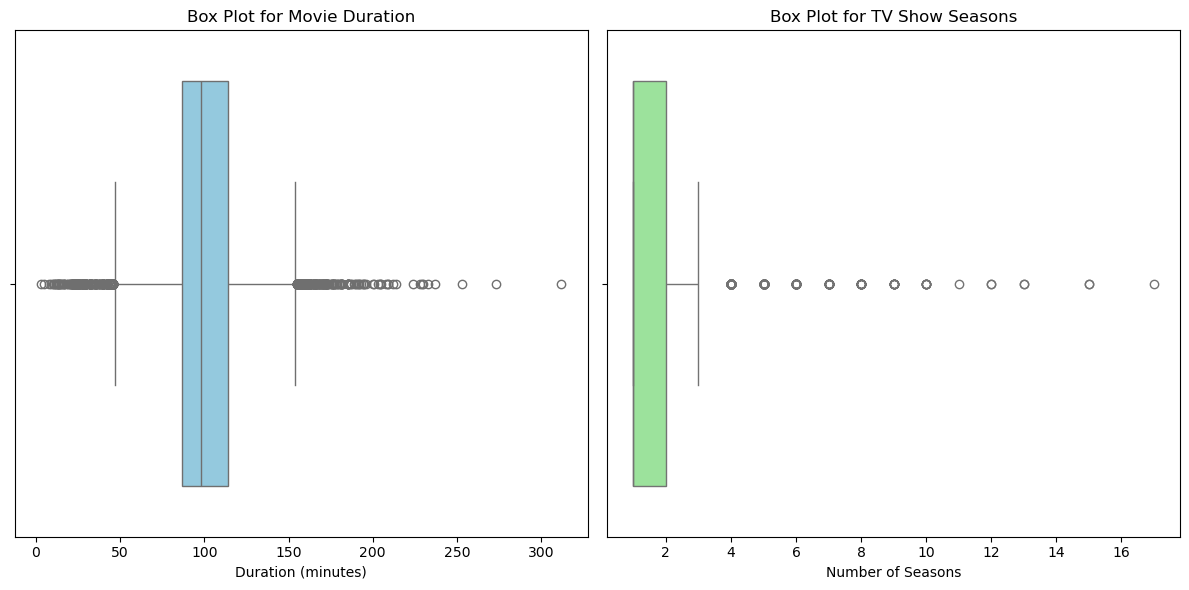

In [82]:
# Filter the data for movies and TV shows separately
movies = df_clean[df_clean['type'] == 'Movie']
tv_shows = df_clean[df_clean['type'] == 'TV Show']

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Box plot for movie duration
sns.boxplot(data=movies, x='movie_duration', ax=axes[0], color='skyblue')
axes[0].set_title('Box Plot for Movie Duration')
axes[0].set_xlabel('Duration (minutes)')

# Box plot for TV show seasons
sns.boxplot(data=tv_shows, x='tv_show_seasons', ax=axes[1], color='lightgreen')
axes[1].set_title('Box Plot for TV Show Seasons')
axes[1].set_xlabel('Number of Seasons')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

In [ ]:
def movie_api_length(row):
    if row['type'] == 'Movie':
        params['t'] = row['title']
        r = requests.get(url, params).json()
        runtime = r.get('Runtime', None)
        if runtime:
            dur = int(runtime.split()[0])
        if dur == row['movie_duration']:
            return True
        else:
            return False

In [91]:
df_api_clean['duration_check'] = df_api_clean.apply(movie_api_length, axis=1)
df_api_clean[df_api_clean['duration_check'] == False]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,year_added,movie_duration,tv_show_seasons,minimum_age,duration_check


In [84]:
df_api_clean[df_api_clean['movie_duration'] < 60][['title', 'movie_duration']].sort_values(by='movie_duration', ascending=True)

,title,movie_duration
3777,Silent,3.0
2713,Sol Levante,5.0
1484,Cops and Robbers,8.0
1557,Canvas,9.0
3535,American Factory: A Conversation with the Obamas,10.0
...,...,...
3623,Enter the Anime,59.0
5230,Christina P: Mother Inferior,59.0
5480,Tracy Morgan: Staying Alive,59.0
3929,Liss Pereira: Reteniendo líquidos,59.0
